例 14.9 每个环境单元包括空气、水分、土壤、作物四个要素. 环境单元的污染状况由污染物在四个要素中含量的超限度来描述.

现有五个环境单元, 它们的污染数据如下.

设 $ U = \{ \text{I}, \text{II}, \text{III}, \text{IV}, \text{V} \} $, $ \text{I} = (5, 5, 3, 2) $, $ \text{II} = (2, 3, 4, 5) $, $ \text{III} = (5, 5, 2, 3) $, $ \text{IV} = (1, 5, 3, 1) $, $ \text{V} = (2, 4, 5, 1) $, 试对 $ U $ 分类.

解 首先, 分别用 $ i = 1, 2, \cdots, 5 $ 表示五个环境单元 I, II, III, IV, V; 用 $ x_j $ ($ j = 1, 2, 3, 4 $) 表示空气、水分、土壤、作物四个指标变量; 第 $ i $ 个环境单元的第 $ j $ 个指标变量的取值记作 $ a_{ij} $, 则第 $ i, j $ 环境单元之间的曼哈顿距离
$$ d_{ij} = \sum_{k = 1}^4 |a_{ik} - a_{jk}|, \quad i, j = 1, 2, \cdots, 5, $$

取相似系数
$$ r_{ij} = 1 - 0.1 d_{ij}, \quad i, j = 1, 2, \cdots, 5. $$

求得 $ F $ 相似矩阵
$$ \boldsymbol{R} = \begin{bmatrix} 
1 & 0.1 & 0.8 & 0.5 & 0.3 \\
0.1 & 1 & 0.1 & 0.2 & 0.4 \\
0.8 & 0.1 & 1 & 0.3 & 0.1 \\
0.5 & 0.2 & 0.3 & 1 & 0.6 \\
0.3 & 0.4 & 0.1 & 0.6 & 1 
\end{bmatrix}. $$

其次, 用平方法求得传递闭包
$$ t(\boldsymbol{R}) = \begin{bmatrix} 
1 & 0.4 & 0.8 & 0.5 & 0.5 \\
0.4 & 1 & 0.4 & 0.4 & 0.4 \\
0.8 & 0.4 & 1 & 0.5 & 0.5 \\
0.5 & 0.4 & 0.5 & 1 & 0.6 \\
0.5 & 0.4 & 0.5 & 0.6 & 1 
\end{bmatrix}, $$

也就是所求的等价矩阵.

最后, 聚类:

- 当 $ 0 \leqslant \lambda \leqslant 0.4 $ 时, $ U $ 分为一类: $ \{ \text{I}, \text{II}, \text{III}, \text{IV}, \text{V} \} $;
- 当 $ 0.4 < \lambda \leqslant 0.5 $ 时, $ U $ 分为二类: $ \{ \text{I}, \text{III}, \text{IV}, \text{V} \}, \{ \text{II} \} $;
- 当 $ 0.5 < \lambda \leqslant 0.6 $ 时, $ U $ 分为三类: $ \{ \text{I}, \text{III} \}, \{ \text{IV}, \text{V} \}, \{ \text{II} \} $;
- 当 $ 0.6 < \lambda \leqslant 0.8 $ 时, $ U $ 分为四类: $ \{ \text{I}, \text{III} \}, \{ \text{II} \}, \{ \text{IV} \}, \{ \text{V} \} $;
- 当 $ 0.8 < \lambda \leqslant 1 $ 时, $ U $ 分为五类: $ \{ \text{I} \}, \{ \text{II} \}, \{ \text{III} \}, \{ \text{IV} \}, \{ \text{V} \} $.



模糊相似矩阵:
[[1.  0.1 0.8 0.5 0.3]
 [0.1 1.  0.1 0.2 0.4]
 [0.8 0.1 1.  0.3 0.1]
 [0.5 0.2 0.3 1.  0.6]
 [0.3 0.4 0.1 0.6 1. ]]
传递闭包举证(模糊等价矩阵):
[[1.  0.4 0.8 0.5 0.5]
 [0.4 1.  0.4 0.4 0.4]
 [0.8 0.4 1.  0.5 0.5]
 [0.5 0.4 0.5 1.  0.6]
 [0.5 0.4 0.5 0.6 1. ]]

-------------------



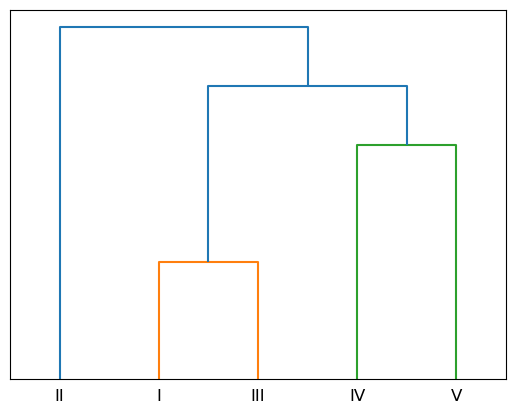

In [22]:
import numpy as np
import scipy.cluster.hierarchy as sch
import matplotlib.pyplot as plt

# 合并运算
def hecheng(a, b):  # a(m, n)，b(n, l)
    m, N = a.shape  # 拆包, m=m, N=n
    n = b.shape[1]  # b的列数, n=l
    c = np.zeros((m, n))  # 合并运算得到的矩阵(m, l)
    for i in range(m):
        for j in range(n):
            c[i, j] = max([min(a[i, k], b[k, j]) for k in range(N)])  # a的一行元素(n个)与b的一列元素(n个)先求最小，后取这n各元素的最大
    return c

A = np.array([[5, 5, 3, 2], [2, 3, 4, 5], [5, 5, 2, 3], [1, 5, 3, 1], [2, 4, 5, 1]])  # (5, 4)
# 注意中括号的使用, i的循环求每行(每个环境单元)和第j行的距离
distance = np.array([[sum(abs(A[i] - A[j])) for i in range(5)] for j in range(5)])  # (5, 5)
r = 1 - 0.1 * distance  # 广播, (5, 5)，得到模糊相似矩阵
print(f"模糊相似矩阵:\n{r}")
R = hecheng(r, r)  # R o R(即 R^2)
# 平方法求传递闭包矩阵
while abs(r - R).sum() > 0.0001:
    r = R  # 更新 R^(2^i)
    R = hecheng(r, r)  # 计算 R^(2^i) o R^(2^i)
print(f"传递闭包举证(模糊等价矩阵):\n{R}")
print('\n-------------------\n')

distance2 = 1 - R  # 为了画图，再次转换为距离关系
distance2 = np.triu(distance2, 1)
distance2 = distance2[distance2!=0]  # 提取矩阵上三角中的非零元素
results = sch.linkage(distance2)

s = ['I', 'II', 'III', 'IV', 'V']
sch.dendrogram(results, labels=s)  # 画聚类树
plt.yticks([])  # y轴不可见
plt.show()

例 14.10 已知聚类的指标变量为 $ x_1, x_2 $, 四个样本点的数据分别为  
$$ 
\omega_1 = (1, 3),\ \omega_2 = (1.5, 3.2),\ \omega_3 = (1.3, 2.8),\ \omega_4 = (3, 1). 
$$  
试用模糊 $ C $ 均值聚类分析把样本点分成两类.  


解 设模糊 $ C $ 均值聚类算法中 $ m = 2 $. 现要分为两类 $ G_1 $ 和 $ G_2 $ 类. 初始时, 设 $ G_1 = \{\omega_1, \omega_2, \omega_3\}, G_2 = \{\omega_4\} $, 则 $ G_1 $ 类 (各点的隶属度均为 1) 聚类中心的坐标  
$$ 
m_1 = \left( \frac{1 + 1.5 + 1.3}{3},\ \frac{3 + 3.2 + 2.8}{3} \right) = (1.2667, 3.0), 
$$  

$ G_2 $ 类 (各点的隶属度均为 1) 聚类中心的坐标为 $ m_2 = (3, 1) $.  


计算每个数据点到 $ G_1 $ 类中心的距离  
$$ 
d_{11} = \|\omega_1 - m_1\| = \sqrt{(1 - 1.2667)^2 + (3 - 3)} = 0.2667, $$  

类似地, 计算得  
$$ 
d_{12} = 0.3073,\ d_{13} = 0.2028,\ d_{14} = 2.6466, 
$$  


计算得到四个数据点到 $ G_2 $ 类中心的距离分别为  
$$ 
d_{21} = 2.8284,\ d_{22} = 2.6627,\ d_{23} = 2.4759,\ d_{24} = 0. 
$$  


计算四个数据点对 $ G_1 $ 类的隶属度  

$$
\mu_{11} = \frac{\dfrac{1}{d_{11}^2}}{\sum_{k=1}^2 \dfrac{1}{d_{k1}^2}} = 0.9912, \quad
\mu_{12} = \frac{\dfrac{1}{d_{12}^2}}{\sum_{k=1}^2 \dfrac{1}{d_{k2}^2}} = 0.9869,
$$  

$$
\mu_{13} = \frac{\dfrac{1}{d_{13}^2}}{\sum_{k=1}^2 \dfrac{1}{d_{k3}^2}} = 0.9933, \quad
\mu_{14} = \frac{\dfrac{1}{d_{14}^2}}{\sum_{k=1}^2 \dfrac{1}{d_{k4}^2}} = 0.
$$  


同理, 四个数据点对 $ G_2 $ 类的隶属度为  
$$ 
\mu_{21} = 0.0088,\ \mu_{22} = 0.0131,\ \mu_{23} = 0.0067,\ \mu_{24} = 1.0. $$  


重新计算聚类中心:  

对 $ G_1 $ 类,  
$$
m_1 = \frac{\sum_{j=1}^4 \mu_{1j}^2 \omega_j}{\sum_{j=1}^4 \mu_{1j}^2} = (1.2660,\ 2.9991).
$$  


对 $ G_2 $ 类, 类似计算得聚类中心 $ m_2 = (2.9995,\ 1.0006) $.  


即得新的聚类中心为: $ m_1 = (1.2660, 2.9991) $, $ m_2 = (2.9995, 1.0006) $. 利用式 (14.14), 计算得到聚类损失函数 $ J_f = 0.2045 $.  


因此, 在 0.001 的误差范围内, 认为得到的新聚类中心与前面的相同, 没有改变, 聚类结束. 根据最大隶属度原则, 把 $\omega_1, \omega_2, \omega_3$ 聚为一类, $\omega_4$ 自成一类.  



### ```skfuzzy.cliuster.cmeans```(science kits fuzzy模糊数学)

'''
cntr：聚类中心  
u：最后的隶属度矩阵  
u0：初始化的隶属度矩阵  
d：是一个矩阵，记录每一个点到聚类中心的欧式距离  
jm：是目标函数的优化历史  
p：p是迭代的次数  
fpc：全称是fuzzy partition coefficient， 是一个评价分类好坏的指标，它的范围是0到1, 1表示效果最好，后面可以通过它来选择聚类的个数。  
'''

```python
import skfuzzy as fuzz

cntr, u, u0, d, jm, p, fpc = fuzz.cluster.cmeans(data.T, 4, 2, error=0.0001, maxiter=1000)
```


In [ ]:
# 每次与运行结果不同
import numpy as np
from skfuzzy.cluster import cmeans

a = np.array([[1, 3], [1.5, 3.2], [1.3, 2.8], [3, 1]])
# 注意a.T
cntr, u, u0, d, jm, p, fpc = cmeans(a.T, c=2, m=2, error=0.005, maxiter=1000)
print(cntr, '\n--------------------\n')
print(u, '\n--------------------\n')
print(u0, '\n--------------------\n')
print(d, '\n--------------------\n')
print(jm, '\n--------------------\n')
print(p, '\n--------------------\n')
print(fpc, '\n--------------------\n')


[[1.26603923 2.99908757]
 [2.99950631 1.00062091]] 
--------------------

[[9.91225527e-01 9.86756038e-01 9.93385761e-01 8.98552528e-08]
 [8.77447291e-03 1.32439617e-02 6.61423934e-03 9.99999910e-01]] 
--------------------

[[0.33636552 0.68097966 0.70429673 0.36548218]
 [0.66363448 0.31902034 0.29570327 0.63451782]] 
--------------------

[[2.66040798e-01 3.08388465e-01 2.01963348e-01 2.64631273e+00]
 [2.82763899e+00 2.66191427e+00 2.47509330e+00 7.93255187e-04]] 
--------------------

[2.74156791 1.38537865 0.21060004 0.20452086] 
--------------------

4 
--------------------

0.9858316891424084 
--------------------

